# `figures-2.ipynb`

Notebook for generating and tweaking EEML 2026 figure components.
All plotting functions live in `visualization.py`.

**To pick up changes:** run the reload cell (cell 1), then re-run the plot cell.

In [86]:
from __future__ import annotations

import importlib
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# Import as module so reload() works — no need to re-import names
import visualization as viz
importlib.reload(viz)

# --- Path config (edit these if your data lives elsewhere) ---

data_dir = Path("data/260327_eeml")
results_main = Path("results/sample_efficiency_30seeds_main_results.json")
results_edge = Path("results/sample_efficiency_edge_ablation_30seeds_results.json")
outdir = Path("figures")
outdir.mkdir(exist_ok=True)


def pick_example_instance(root: Path, cls: str = "var-chain") -> Path:
    for candidate in sorted((root / cls).glob("M10_T500_I*")):
        if (candidate / "timeseries.npy").exists() and (candidate / "spi_mpis.npz").exists():
            return candidate
    raise FileNotFoundError(f"No example instance found in {root / cls}")


instance = pick_example_instance(data_dir, "var-chain")
npz_path = instance / "spi_mpis.npz"
ts_path = instance / "timeseries.npy"

print(f"instance: {instance}")
print(f"results:  {results_main}")

instance: data/260327_eeml/var-chain/M10_T500_I10
results:  results/sample_efficiency_30seeds_main_results.json


## Apply style

In [87]:
viz.apply_style()
plt.rcParams["font.family"], plt.rcParams["font.size"]

(['serif'], 8.0)

## Load results

In [88]:
results = viz.load_results(results_main)
{
    "n_values": list(results["results"].keys())[:5],
    "models_at_smallest_n": list(results["results"][sorted(results["results"], key=int)[0]]["models"].keys()),
}

{'n_values': ['20', '50', '100', '200', '500'],
 'models_at_smallest_n': ['spi-mpnn',
  'fixed-spi',
  'mlp-mix',
  'correlation',
  'latent',
  'shuffled',
  'node-only']}

## Motif graphs

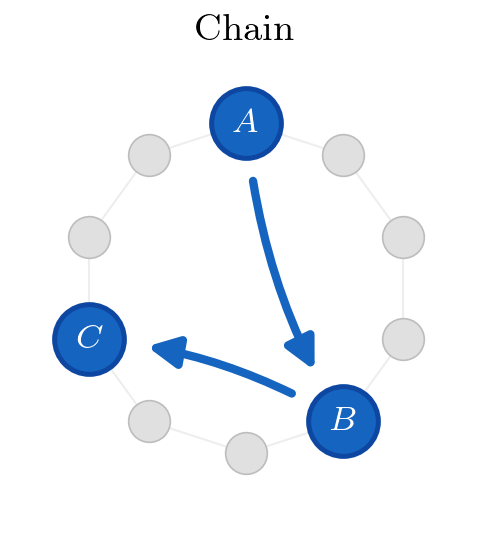

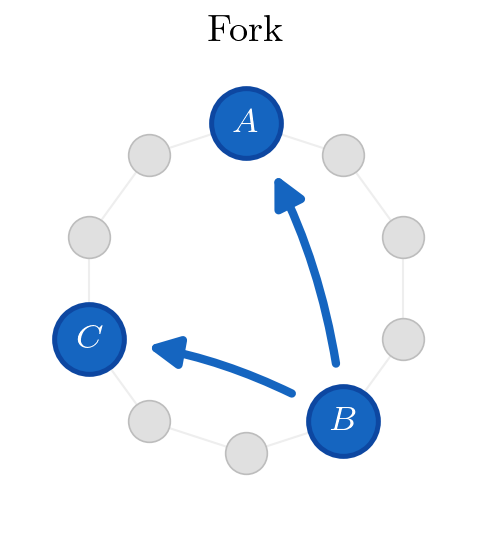

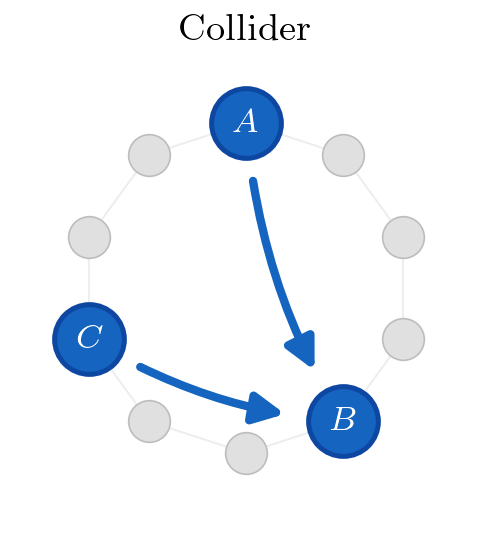

In [89]:
viz.apply_style()
for motif in ["Chain", "Fork", "Collider"]:
    fig, ax = viz.plot_motif_graph(motif, M=10)
    # fig.savefig(outdir / f"fig1a_motif_{motif.lower()}.pdf")
    plt.show()

## Time series

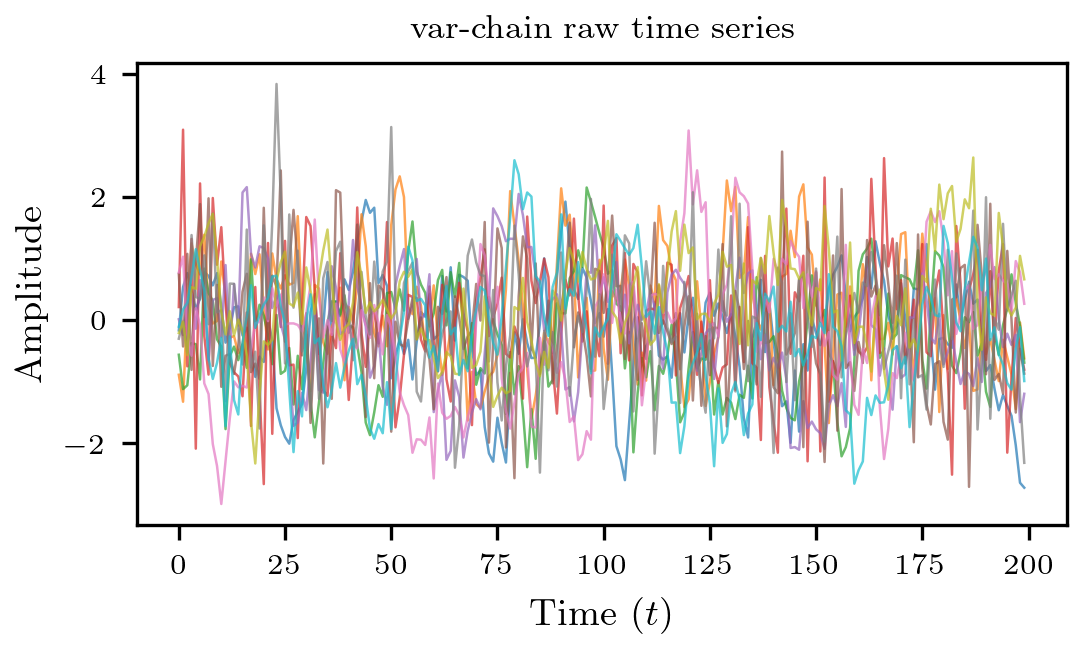

In [90]:
viz.apply_style()
fig, ax = viz.plot_time_series(ts_path, title="var-chain raw time series", max_T=200)
plt.show()

## MTS heatmap

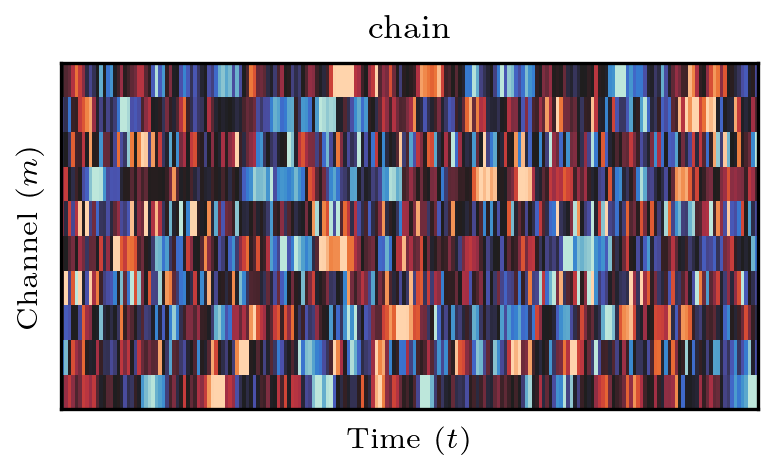

In [91]:
viz.apply_style()
fig, ax = viz.plot_mts_heatmap(ts_path, title="chain")
# fig.savefig(outdir / "fig1a_mts_var-chain.pdf")
plt.show()

## MPI (SPI matrix) heatmaps

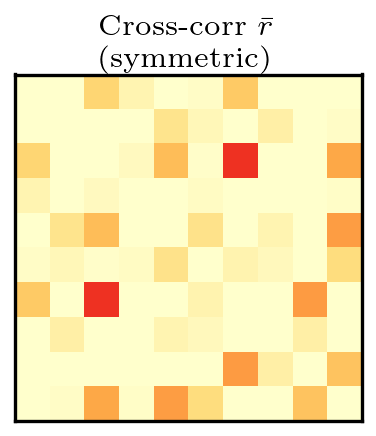

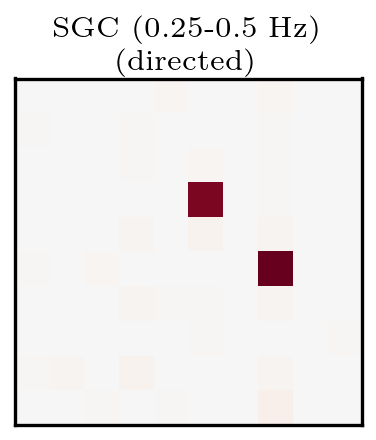

In [92]:
viz.apply_style()

# Symmetric example
fig, ax = viz.plot_mpi_heatmap(
    npz_path,
    "xcorr_mean_sig-True",
    title=r"Cross-corr $\bar{r}$",
)
# fig.savefig(outdir / "fig1b_mpi_xcorr_mean_sig_True.pdf")
plt.show()

# Directed example
fig, ax = viz.plot_mpi_heatmap(
    npz_path,
    "sgc_parametric_mean_fs-1_fmin-0-25_fmax-0-5_order-1",
    title="SGC (0.25-0.5 Hz)",
)
# fig.savefig(outdir / "fig1b_mpi_sgc_parametric_mean_.pdf")
plt.show()

## Sample efficiency

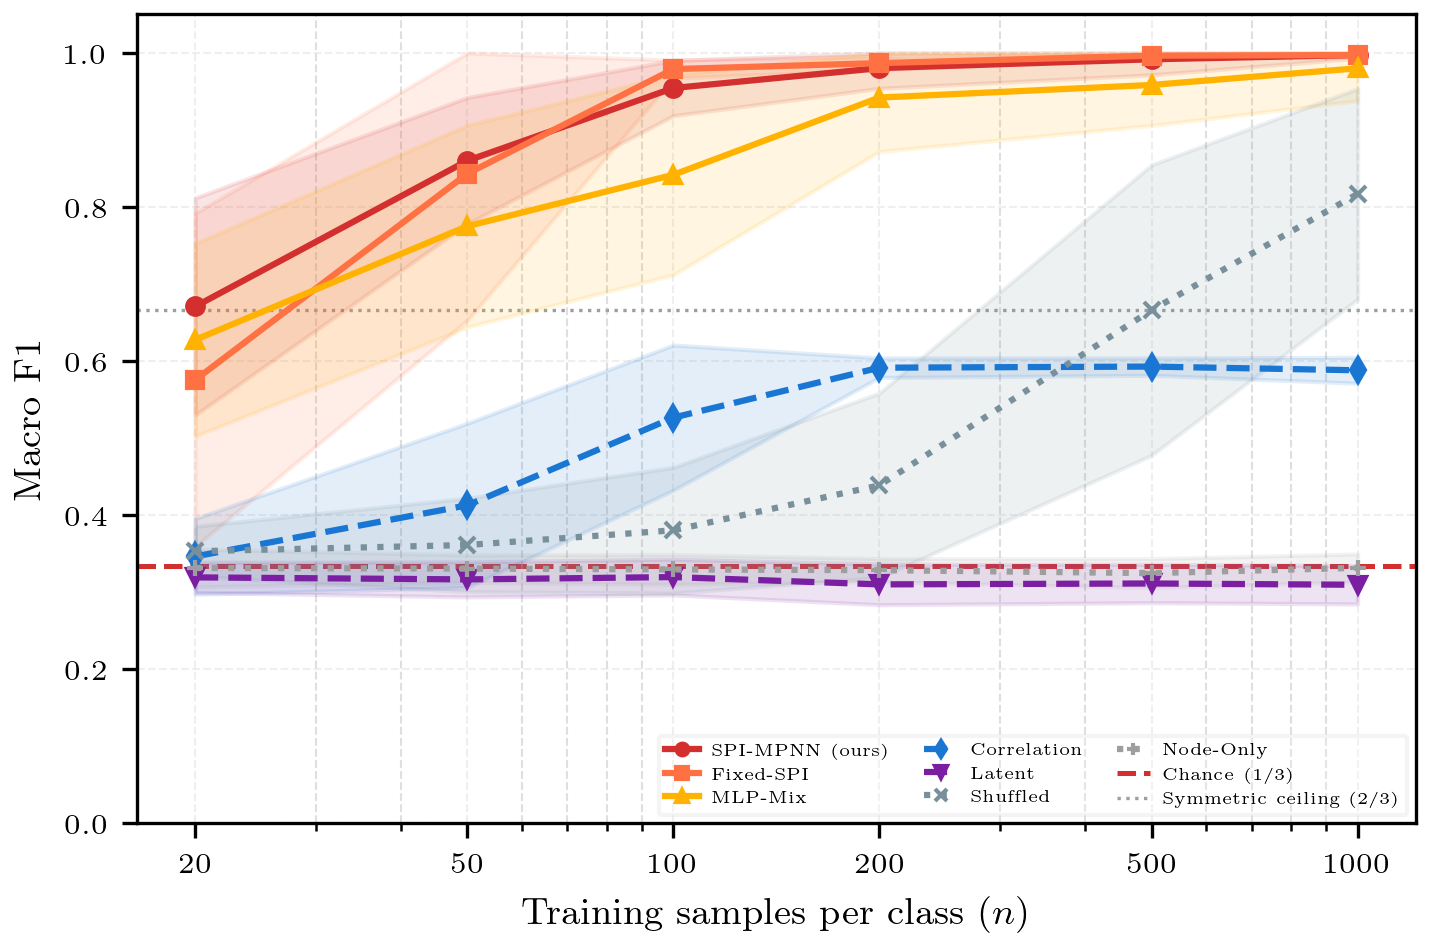

In [121]:
import importlib
import visualization 
importlib.reload(visualization)
from visualization import plot_sample_efficiency

visualization.apply_style()
fig, ax = plot_sample_efficiency(
    results_main,
    models=["spi-mpnn", "fixed-spi", "mlp-mix", "correlation", "latent", "shuffled", "node-only"],
)
# fig.savefig(outdir / "fig2a_sample_efficiency.pdf")
plt.show()

## Sample efficiency (multi-source, with edge ablation)

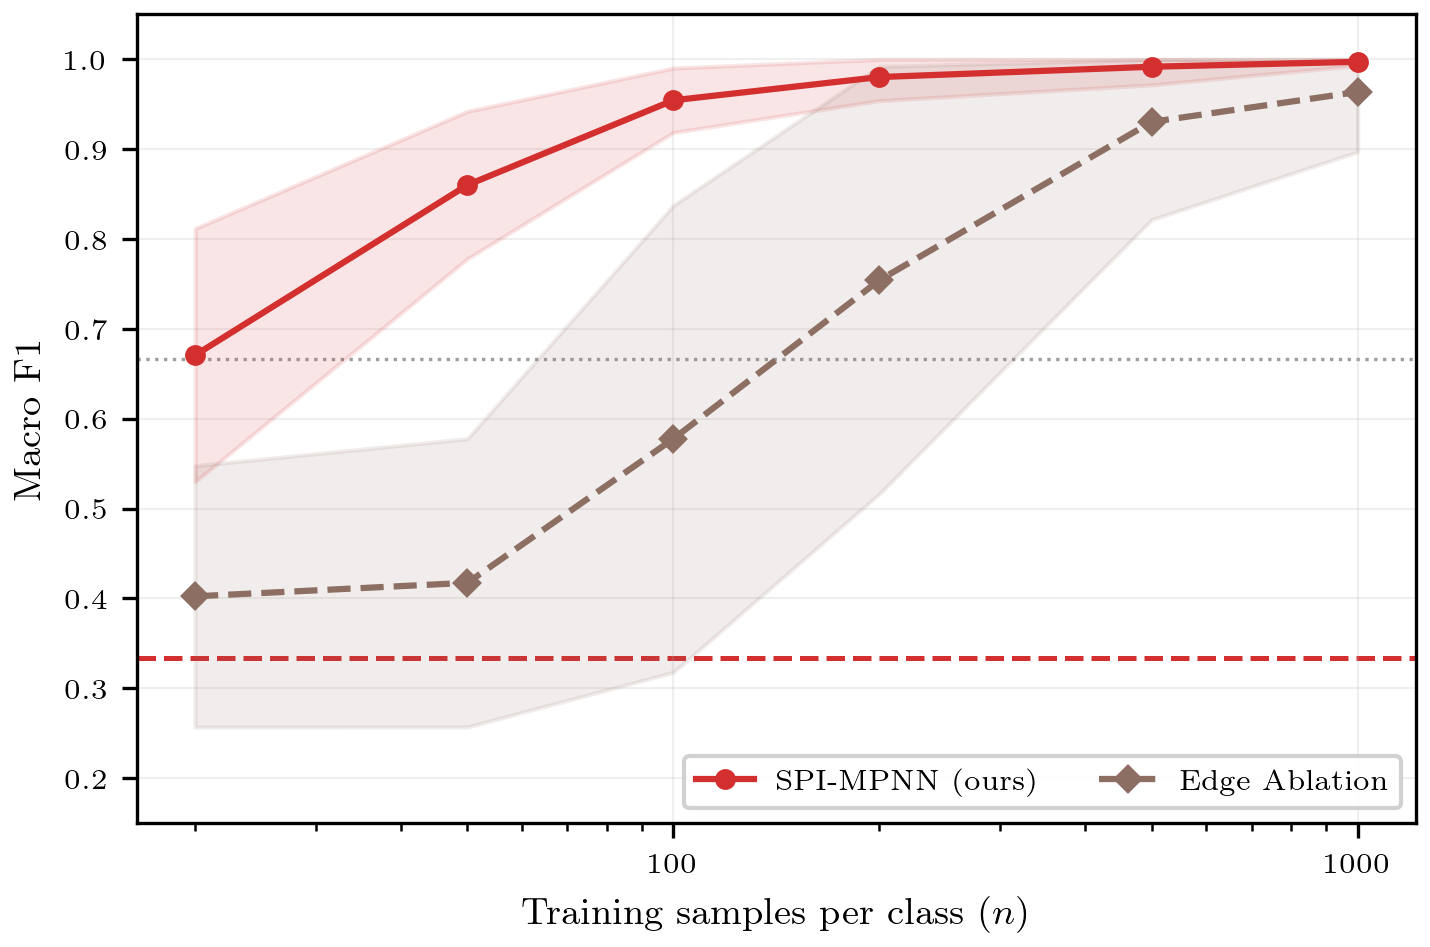

In [94]:
viz.apply_style()
fig, ax = viz.plot_sample_efficiency_multi(
    {
        "spi-mpnn": results_main,
        "edge-ablation": results_edge,
    },
    models=["spi-mpnn", "edge-ablation"],
)
plt.show()

## Edge ablation overlay

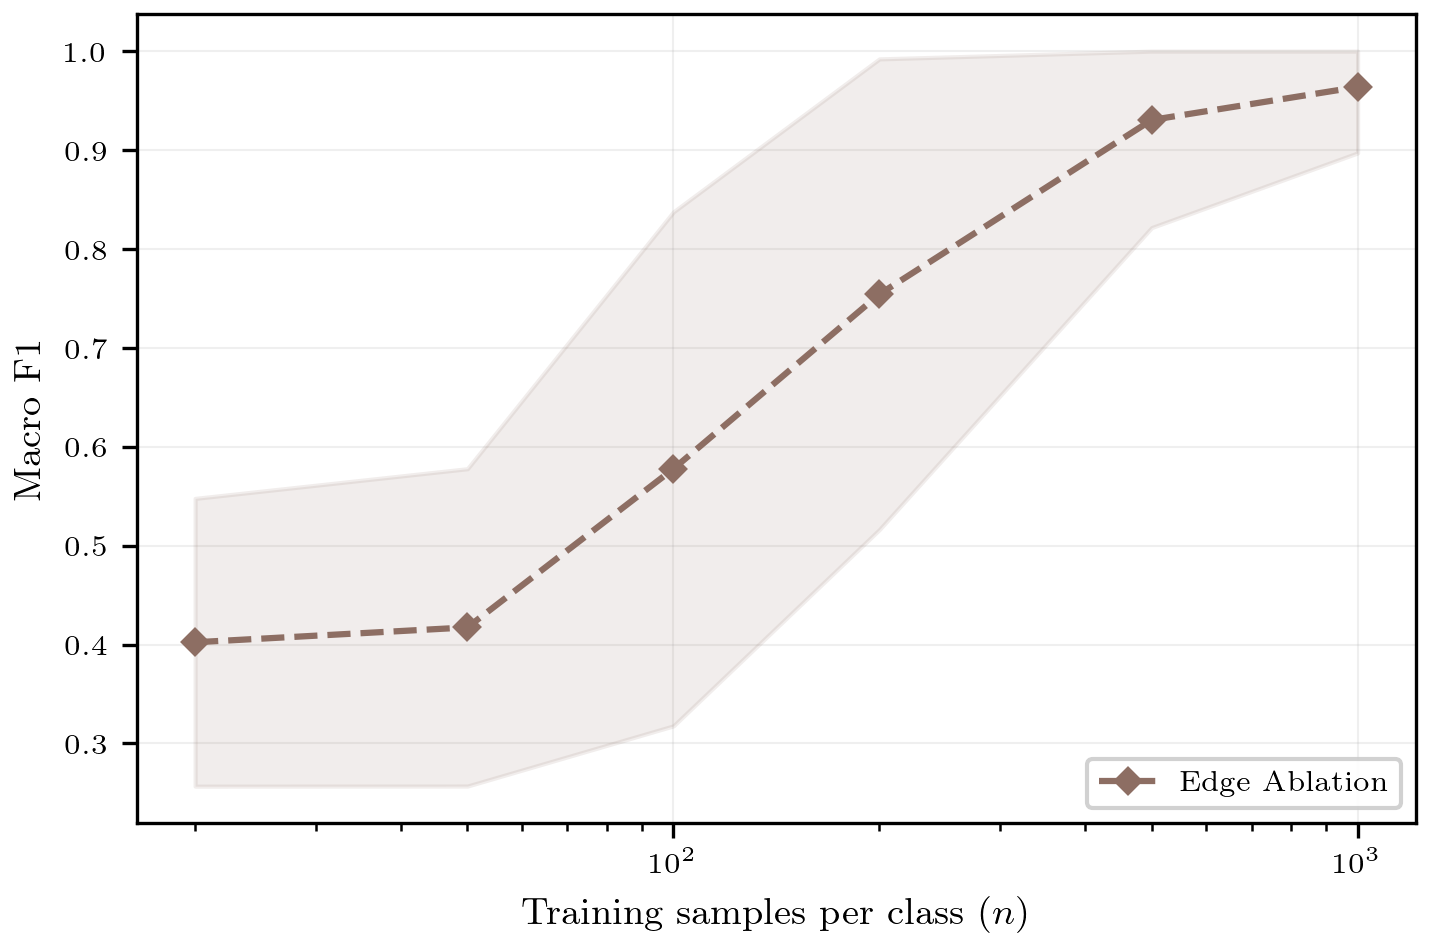

In [95]:
viz.apply_style()
fig, ax = plt.subplots(1, 1, figsize=(5.5, 3.5))
viz.overlay_model(ax, results_edge, "edge-ablation")
ax.set_xscale("log")
ax.set_xlabel(r"Training samples per class ($n$)")
ax.set_ylabel("Macro F1")
ax.legend(loc="lower right", framealpha=0.9)
ax.grid(True, alpha=0.2, linewidth=0.5)
plt.show()

## Family weights (violin + dots)

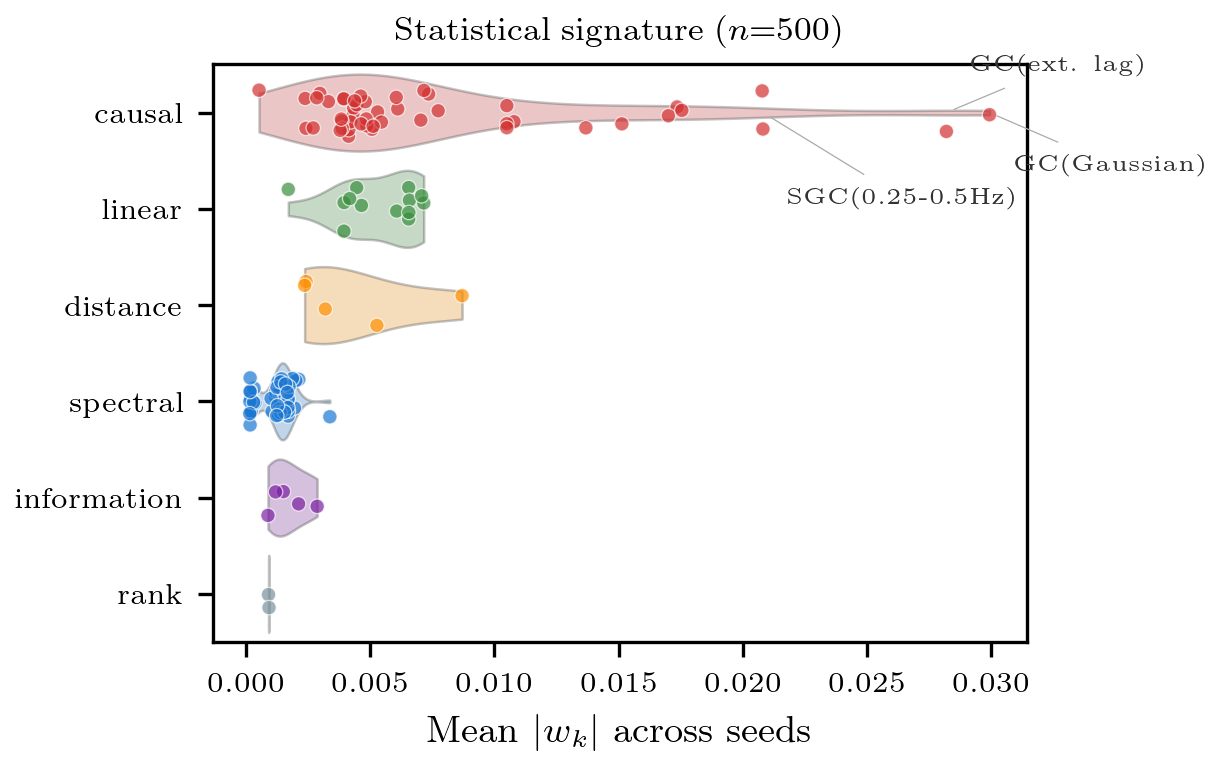

In [96]:
viz.apply_style()
fig, ax = viz.plot_family_weights(results_main, n_value=500)
# fig.savefig(outdir / "fig1c_family_violin.pdf")
plt.show()

## Per-seed strip plot

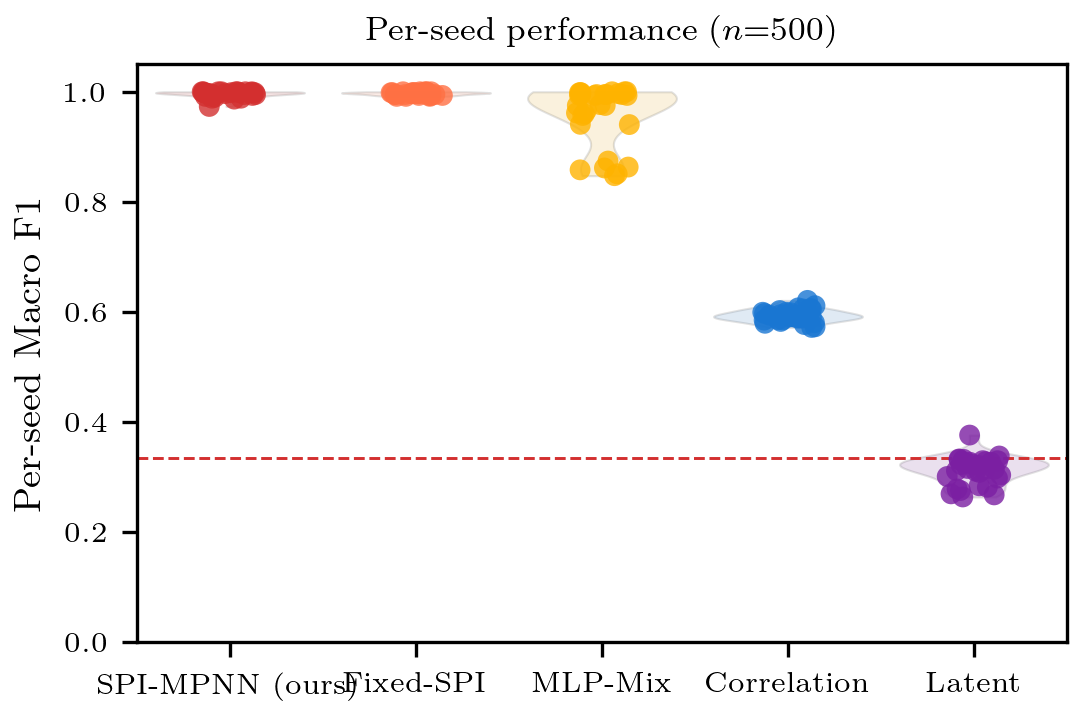

In [97]:
viz.apply_style()
fig, ax = viz.plot_per_seed_strip(
    results_main,
    n_value=500,
    models=["spi-mpnn", "fixed-spi", "mlp-mix", "correlation", "latent"],
    show_violin=True,
    exclude_below={"spi-mpnn": 0.9},
)
# fig.savefig(outdir / "fig2c_per_seed_strip.pdf")
plt.show()

## Save all figures
Uncomment and run when you're happy with the plots.

In [98]:
# viz.apply_style()
# for motif in ["Chain", "Fork", "Collider"]:
#     fig, _ = viz.plot_motif_graph(motif, M=10)
#     fig.savefig(outdir / f"fig1a_motif_{motif.lower()}.pdf")
# fig, _ = viz.plot_mts_heatmap(ts_path, title="chain")
# fig.savefig(outdir / "fig1a_mts_var-chain.pdf")
# fig, _ = viz.plot_sample_efficiency(results_main)
# fig.savefig(outdir / "fig2a_sample_efficiency.pdf")
# fig, _ = viz.plot_family_weights(results_main, n_value=500)
# fig.savefig(outdir / "fig1c_family_violin.pdf")
# fig, _ = viz.plot_per_seed_strip(results_main, n_value=500, exclude_below={"spi-mpnn": 0.9})
# fig.savefig(outdir / "fig2c_per_seed_strip.pdf")
# print("All saved.")

## Run `visualization.py` CLI (saves all figures)

In [99]:
# !python visualization.py